In [1]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Student Perfomance/student-mat.csv", sep=";")

print(df.head())
print(df.shape)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
(395, 33)


In [2]:
print(df.columns)

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')


In [3]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

,0
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


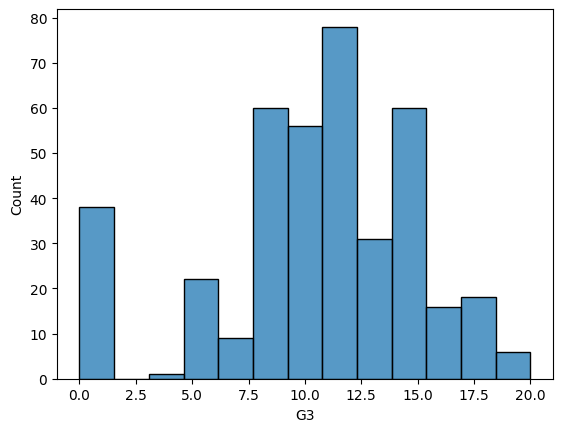

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["G3"])
plt.show()

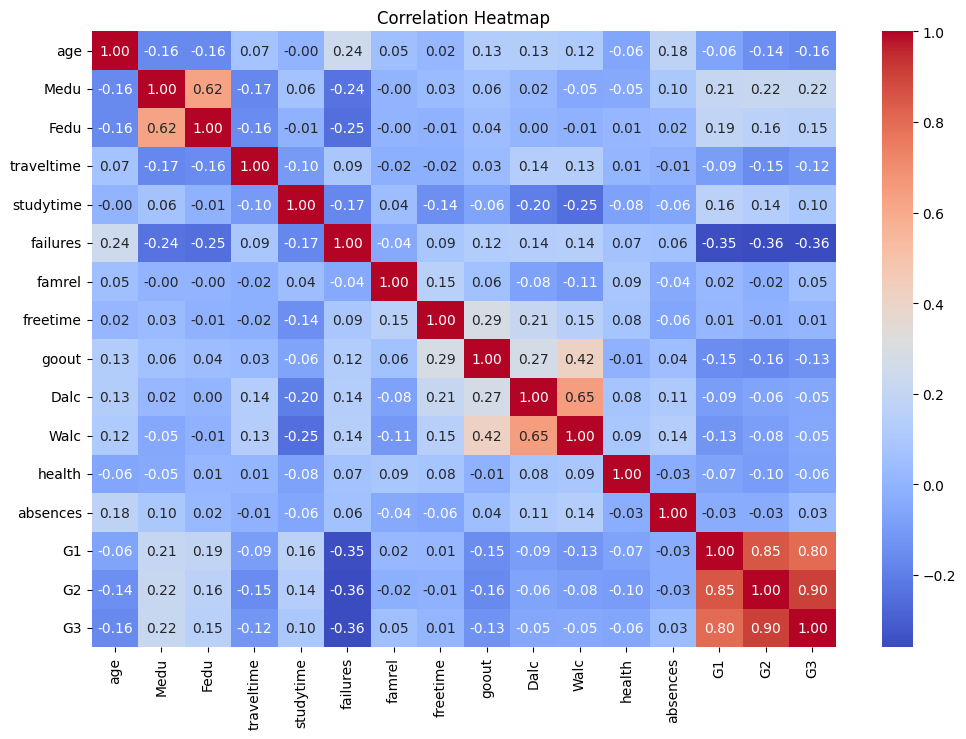

In [5]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

In [6]:
corr_with_g3 = corr_matrix["G3"].sort_values(ascending=False)

print(corr_with_g3)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64


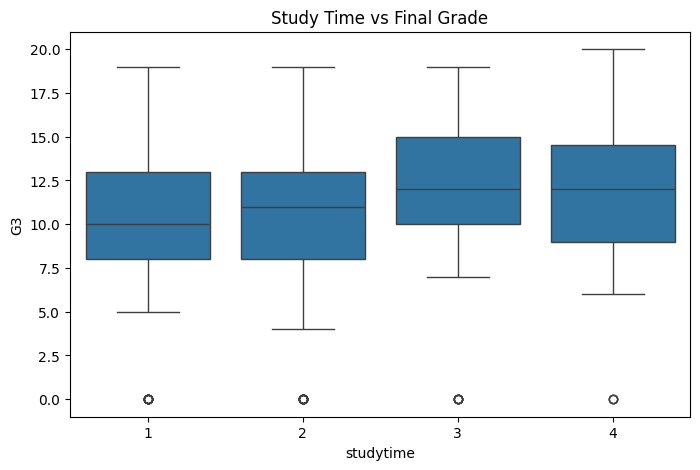

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x="studytime", y="G3", data=df)
plt.title("Study Time vs Final Grade")
plt.show()

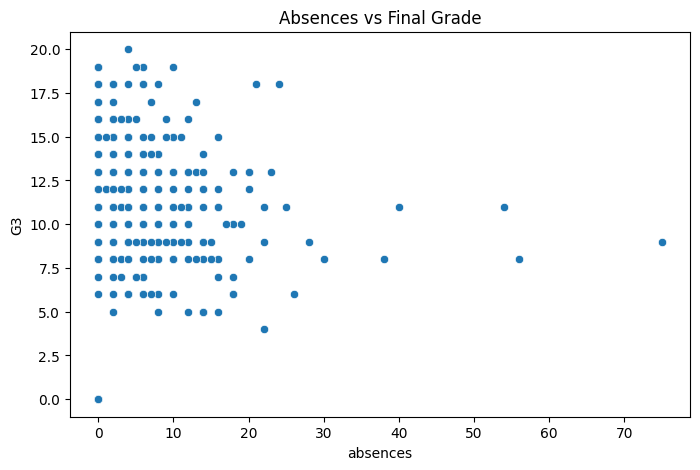

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="absences", y="G3", data=df)
plt.title("Absences vs Final Grade")
plt.show()

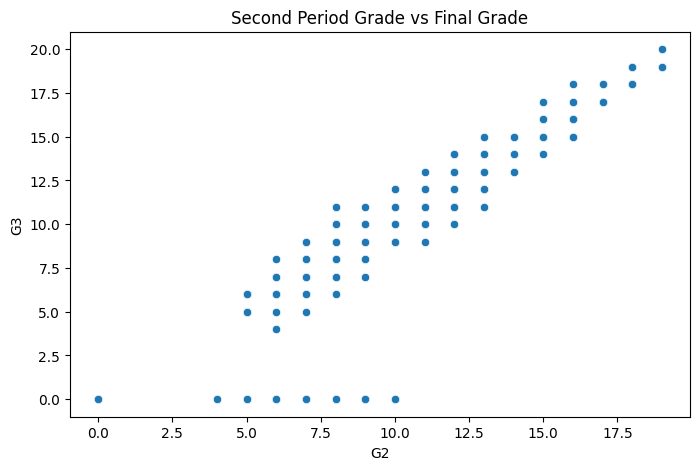

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="G2", y="G3", data=df)
plt.title("Second Period Grade vs Final Grade")
plt.show()

**EDA Summary**
Exploratory Data Analysis revealed that previous academic performance
was the strongest predictor of final grades.

Key findings:

• G2 showed the highest correlation with G3 (0.90).

• G1 also demonstrated a strong positive relationship with G3 (0.80).

• Previous failures negatively impacted academic performance (-0.36).

• Study time had a weak positive influence on grades.

• Absences showed little direct correlation with final performance.

• Students with higher parental education levels tended to achieve
  slightly better results.


In [10]:
X = df.drop("G3", axis=1)
y = df["G3"]

In [11]:
categorical_cols = X.select_dtypes(include="object").columns

print(categorical_cols)

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_cols
        )
    ],
    remainder="passthrough"
)

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
print(X_train.shape)
print(X_test.shape)

(316, 32)
(79, 32)


In [15]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object'))])),
                ('model', LinearRegression())])

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, preds)
lr_rmse = mean_squared_error(y_test, preds) ** 0.5
lr_r2 = r2_score(y_test, preds)

print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2:", lr_r2)

MAE: 1.6466656197147522
RMSE: 2.3783697847961376
R2: 0.7241341236974019


In [17]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object'))])),
                ('model', RandomForestRegressor(random_state=42))])

In [18]:
rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = mean_squared_error(y_test, rf_preds) ** 0.5
rf_r2 = r2_score(y_test, rf_preds)

print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2:", rf_r2)

MAE: 1.1918987341772151
RMSE: 1.9963187640241566
R2: 0.8056435298346514


In [19]:
pip install xgboost

In [20]:
from xgboost import XGBRegressor

xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=4,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object'))])),
                ('model',
                 XGBRegressor(base_...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=100, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [21]:
xgb_preds = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_preds)
xgb_rmse = mean_squared_error(y_test, xgb_preds) ** 0.5
xgb_r2 = r2_score(y_test, xgb_preds)

print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)
print("R2:", xgb_r2)

MAE: 1.1710186004638672
RMSE: 2.0184977559853685
R2: 0.8013010025024414


In [22]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    "R2": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,1.646666,2.378370,0.724134
1,Random Forest,1.191899,1.996319,0.805644
2,XGBoost,1.171019,2.018498,0.801301


In [23]:
import pandas as pd
import numpy as np

feature_names = rf_model.named_steps[
    "preprocessor"
].get_feature_names_out()

importances = rf_model.named_steps[
    "model"
].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance_df.head(15))

                 Feature  Importance
57         remainder__G2    0.792475
55   remainder__absences    0.109735
21      cat__reason_home    0.019012
43        remainder__age    0.010589
56         remainder__G1    0.006552
49     remainder__famrel    0.004572
20    cat__reason_course    0.004123
51      remainder__goout    0.004072
54     remainder__health    0.003763
47  remainder__studytime    0.002940
53       remainder__Walc    0.002520
42     cat__romantic_yes    0.002352
25  cat__guardian_mother    0.002159
45       remainder__Fedu    0.002118
34   cat__activities_yes    0.001976


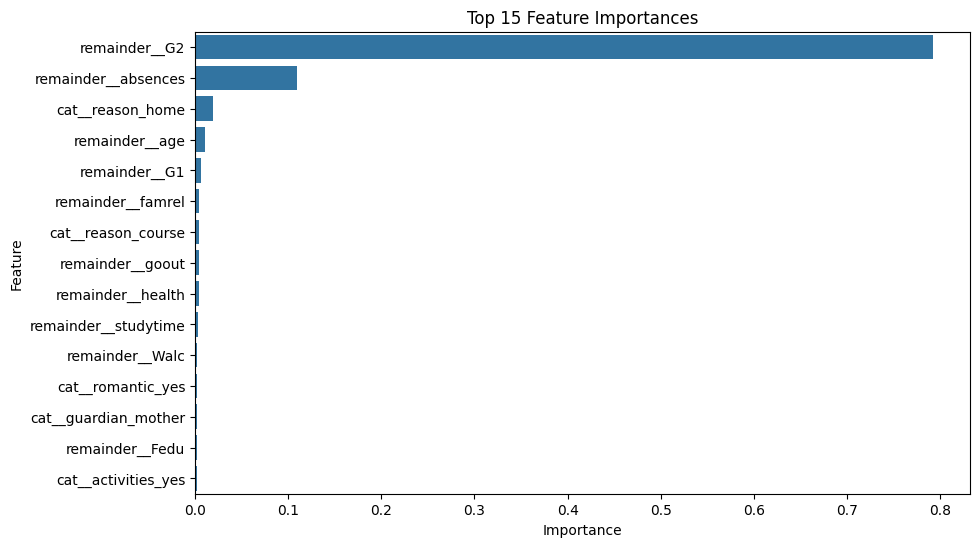

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(15)

plt.figure(figsize=(10,6))
sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances")
plt.show()